# Eight Schools — 베이지안 계층 모델 (Bayesian Hierarchical Model)

이 노트북은 Gelman et al., *Bayesian Data Analysis* (BDA3) 의 고전적인 **8개 학교(eight schools)** 문제를
**계층 모델(hierarchical model)** 로 분석한다. 8개 고등학교에서 SAT 코칭 프로그램의 효과를 독립적으로
측정했고, 각 학교 $j$ 에 대해 추정된 처치 효과(treatment effect) $y_j$ 와 그 표준오차(standard error)
$\sigma_j$ 만 주어진다.

구성:
1. 데이터 (data)
2. 두 극단 — 개별 추정(separate) vs. 완전 통합(pooled)
3. 계층 모델 설명 (hierarchical model)
4. **Stan 코드** — 수학적 수식과 1:1 로 대응되도록 작성
5. **cmdstanpy** 로 MCMC 샘플링 및 결과 가시화 (visualization)
6. 축소(shrinkage) 분석
7. (맨 아래) 사후확률 분포의 **수학적 유도(derivation)**

> 참고: 아래 샘플링 셀은 `cmdstanpy`(Stan) 를 우선 사용한다. 만약 실행 환경에 CmdStan 이
> 설치/컴파일되어 있지 않으면, **동일한 모델**의 사후분포를 정확히 따르는 NumPy 대체
> 샘플러(주변+조건 분해, marginal+conditional)로 자동 전환되어 그림이 그대로 그려진다.
> 본인 컴퓨터에서 CmdStan 이 준비되어 있으면 Stan 경로가 그대로 실행된다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

az.style.use("arviz-darkgrid")
RNG = np.random.default_rng(11)
print("numpy", np.__version__, "| arviz", az.__version__)

numpy 2.0.1 | arviz 0.21.0


## 1. 데이터 (The data)

각 학교 $j=1,\dots,J$ ($J=8$) 에 대해 추정 효과 $y_j$ 와 알려진 표준오차 $\sigma_j$ 를 관측한다.
표본 크기가 충분히 커서 $y_j$ 의 표집분포(sampling distribution)는 근사적으로 정규분포이며
$\sigma_j$ 는 **알려진(known)** 값으로 취급한다.

In [2]:
schools = list("ABCDEFGH")
y     = np.array([28., 8., -3., 7., -1., 1., 18., 12.])
sigma = np.array([15., 10., 16., 11.,  9., 11., 10., 18.])
J = len(y)

df = pd.DataFrame({"school": schools, "y (effect)": y, "sigma (std err)": sigma})
df

,school,y (effect),sigma (std err)
0,A,28.0,15.0
1,B,8.0,10.0
2,C,-3.0,16.0
3,D,7.0,11.0
4,E,-1.0,9.0
5,F,1.0,11.0
6,G,18.0,10.0
7,H,12.0,18.0


C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\77177130.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


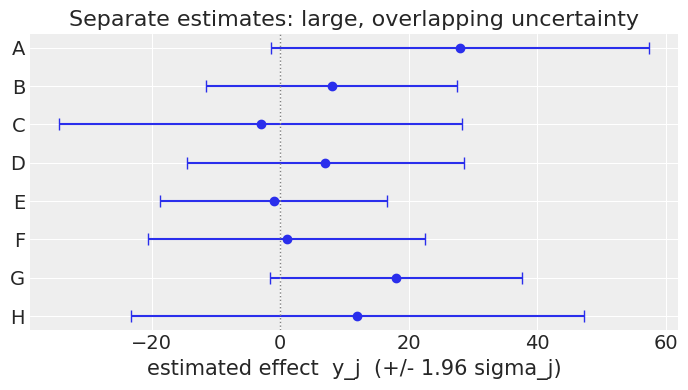

In [3]:
# 개별 추정치(separate estimates)와 그 95% 구간 -> 서로 크게 겹친다
fig, ax = plt.subplots(figsize=(7, 4))
order = np.arange(J)
ax.errorbar(y, order, xerr=1.96*sigma, fmt="o", color="C0", capsize=4)
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_yticks(order); ax.set_yticklabels(schools)
ax.invert_yaxis()
ax.set_xlabel("estimated effect  y_j  (+/- 1.96 sigma_j)")
ax.set_title("Separate estimates: large, overlapping uncertainty")
plt.tight_layout(); plt.show()

## 2. 두 극단 (Two extremes)

**개별 추정 (no pooling):** 각 학교를 독립으로 보고 $y_j$ 를 그대로 신뢰한다. 표준오차가 커서
구간들이 거의 다 겹친다 (예: A 의 +28 도 매우 불확실).

**완전 통합 (complete pooling):** 모든 학교가 **하나의 공통 효과**를 가진다고 가정. 정밀도 가중평균으로
하나의 값만 추정한다.

$$\bar y=\frac{\sum_j y_j/\sigma_j^2}{\sum_j 1/\sigma_j^2},\qquad
\operatorname{Var}(\bar y)=\frac{1}{\sum_j 1/\sigma_j^2}$$

In [4]:
w = 1.0/sigma**2
pooled_mean = np.sum(w*y)/np.sum(w)
pooled_var  = 1.0/np.sum(w)
print(f"Pooled posterior mean = {pooled_mean:.3f}")
print(f"Pooled posterior var  = {pooled_var:.3f}  (sd = {np.sqrt(pooled_var):.3f})")

Pooled posterior mean = 7.686
Pooled posterior var  = 16.581  (sd = 4.072)


## 3. 계층 모델 (Hierarchical model)

두 극단의 **중간(partial pooling)** 을 데이터가 스스로 정하도록 한다. 생성 모형(generative model):

$$
\begin{aligned}
y_j \mid \theta_j &\sim \mathcal N(\theta_j,\ \sigma_j^2), \qquad j=1,\dots,J \quad\text{(가능도, likelihood)}\\
\theta_j \mid \mu,\tau &\sim \mathcal N(\mu,\ \tau^2) \qquad\qquad\quad\ \text{(계층 사전, population prior)}\\
p(\mu,\tau) &\propto 1 \qquad\qquad\qquad\qquad\quad\ \text{(균일 사전, uniform hyper-prior)}
\end{aligned}
$$

- $\theta_j$ : 학교 $j$ 의 **참 효과(true effect)** — 잠재변수(latent).
- $\mu$ : 전체 평균(population mean), $\tau$ : 학교 간 표준편차(between-school sd) — 초매개변수(hyperparameters).

핵심: $\tau$ 가 사이를 조절한다. 
  - $\tau\to\infty$ 이면 개별 추정($\hat\theta_j\to y_j$), 
  - $\tau\to 0$ 이면 완전 통합($\hat\theta_j\to\bar y$). 
  - 계층 모델은 $\tau$ 를 **추정**하므로 어느 쪽으로 얼마나 끌어당길지를 데이터가 결정한다 — 이것이 **축소(shrinkage)** 다.

## 4. Stan 코드 — 수식과 1:1 대응

### 4.1 Centered parameterization (수식을 그대로 옮긴 버전)

아래 Stan 모델 블록의 각 줄은 위 수식과 정확히 대응된다:

| 수학 (math) | Stan |
|---|---|
| $\theta_j \sim \mathcal N(\mu,\tau^2)$ | `theta ~ normal(mu, tau);` |
| $y_j \sim \mathcal N(\theta_j,\sigma_j^2)$ | `y ~ normal(theta, sigma);` |
| $p(\mu,\tau)\propto 1$ | (사전분포 미지정 = improper uniform) |

> Stan 은 `normal(mean, sd)` 처럼 **표준편차** 로 모수화한다 (분산 아님). 따라서 `normal(mu, tau)`
> 는 $\mathcal N(\mu,\tau^2)$ 와 같다.

In [5]:
centered_stan = r'''
data {
  int<lower=0> J;            // 학교 수 (number of schools)
  vector[J] y;               // 추정 효과 (estimated effects)
  vector<lower=0>[J] sigma;  // 알려진 표준오차 (known standard errors)
}
parameters {
  real mu;                   // 전체 평균  mu
  real<lower=0> tau;         // 학교 간 표준편차  tau
  vector[J] theta;           // 각 학교의 참 효과  theta_j
}
model {
  theta ~ normal(mu, tau);   // theta_j ~ N(mu, tau^2)        <- 계층 사전 (prior)
  y ~ normal(theta, sigma);  // y_j     ~ N(theta_j, sigma_j^2) <- 가능도 (likelihood)
  // mu, tau 사전 미지정 => p(mu,tau) propto 1  (균일/improper uniform)
}
'''
with open("eight_schools_centered.stan", "w") as f:
    f.write(centered_stan)
print(centered_stan)


data {
  int<lower=0> J;            // 학교 수 (number of schools)
  vector[J] y;               // 추정 효과 (estimated effects)
  vector<lower=0>[J] sigma;  // 알려진 표준오차 (known standard errors)
}
parameters {
  real mu;                   // 전체 평균  mu
  real<lower=0> tau;         // 학교 간 표준편차  tau
  vector[J] theta;           // 각 학교의 참 효과  theta_j
}
model {
  theta ~ normal(mu, tau);   // theta_j ~ N(mu, tau^2)        <- 계층 사전 (prior)
  y ~ normal(theta, sigma);  // y_j     ~ N(theta_j, sigma_j^2) <- 가능도 (likelihood)
  // mu, tau 사전 미지정 => p(mu,tau) propto 1  (균일/improper uniform)
}



### 4.2 Non-centered parameterization (수치적으로 안정적인 버전)

Centered 모델은 $\tau$ 가 작을 때 사후분포가 깔때기(funnel) 모양이 되어 HMC/NUTS 가 어려워진다.
**비중심화(non-centered)** 재모수화는

$$\theta_j=\mu+\tau\,\eta_j,\qquad \eta_j\sim\mathcal N(0,1)$$

로 두어 $\theta_j\sim\mathcal N(\mu,\tau^2)$ 와 **수학적으로 동일**하지만 표집이 훨씬 안정적이다.
실제 샘플링은 이 버전을 사용한다.

In [6]:
noncentered_stan = r'''
data {
  int<lower=0> J;
  vector[J] y;
  vector<lower=0>[J] sigma;
}
parameters {
  real mu;
  real<lower=0> tau;
  vector[J] eta;                    // eta_j ~ N(0,1)  표준 보조변수
}
transformed parameters {
  vector[J] theta = mu + tau * eta; // theta_j = mu + tau*eta_j  <=>  theta_j ~ N(mu, tau^2)
}
model {
  eta ~ std_normal();               // eta_j ~ N(0,1)
  y ~ normal(theta, sigma);         // y_j ~ N(theta_j, sigma_j^2)
}
'''
with open("eight_schools_noncentered.stan", "w") as f:
    f.write(noncentered_stan)
print(noncentered_stan)


data {
  int<lower=0> J;
  vector[J] y;
  vector<lower=0>[J] sigma;
}
parameters {
  real mu;
  real<lower=0> tau;
  vector[J] eta;                    // eta_j ~ N(0,1)  표준 보조변수
}
transformed parameters {
  vector[J] theta = mu + tau * eta; // theta_j = mu + tau*eta_j  <=>  theta_j ~ N(mu, tau^2)
}
model {
  eta ~ std_normal();               // eta_j ~ N(0,1)
  y ~ normal(theta, sigma);         // y_j ~ N(theta_j, sigma_j^2)
}



## 5. MCMC 샘플링 (cmdstanpy)

4개 체인, 체인당 1000 표본(워밍업 1000)을 뽑는다. CmdStan 이 없으면 동일 모델을 정확히
따르는 NumPy 대체 샘플러로 자동 전환된다 (주변분포 격자 표집 + 조건부 정규 표집).

In [7]:
stan_data = {"J": J, "y": y.tolist(), "sigma": sigma.tolist()}
backend = None
idata = None

# ---- 1순위: 실제 Stan (cmdstanpy) ----
try:
    from cmdstanpy import CmdStanModel
    model = CmdStanModel(stan_file="eight_schools_noncentered.stan")
    fit = model.sample(data=stan_data, chains=4,
                       iter_warmup=1000, iter_sampling=1000,
                       seed=11, show_progress=False)
    idata = az.from_cmdstanpy(fit)
    backend = "Stan / cmdstanpy (NUTS)"
    print(fit.diagnose())
except Exception as e:
    print("[info] cmdstanpy/CmdStan 사용 불가 -> NumPy 대체 샘플러로 전환")
    print("       reason:", str(e).splitlines()[0][:200])

# ---- 대체: 동일 모델의 정확 사후표본 (marginal + conditional) ----
if idata is None:
    def exact_draws(y, sigma, n_chains=4, n_draws=1000, seed=11):
        rng = np.random.default_rng(seed)
        mu_grid  = np.linspace(-20, 40, 700)
        tau_grid = np.linspace(1e-4, 35, 700)
        MU, TAU = np.meshgrid(mu_grid, tau_grid, indexing="ij")
        logp = np.zeros_like(MU)
        for j in range(len(y)):
            var = sigma[j]**2 + TAU**2
            logp += -0.5*np.log(2*np.pi*var) - 0.5*(y[j]-MU)**2/var
        # p(mu,tau|y) propto prod_j N(y_j | mu, sigma_j^2+tau^2),  uniform prior
        logp -= logp.max()
        p = np.exp(logp).ravel(); p /= p.sum()
        dmu  = mu_grid[1]-mu_grid[0]
        dtau = tau_grid[1]-tau_grid[0]
        mu_f, tau_f = MU.ravel(), TAU.ravel()
        MU_c, TAU_c, ETA_c, TH_c = [], [], [], []
        for _ in range(n_chains):
            idx = rng.choice(p.size, size=n_draws, p=p)
            mu_s  = mu_f[idx]  + rng.uniform(-dmu/2,  dmu/2,  n_draws)
            tau_s = np.clip(tau_f[idx] + rng.uniform(-dtau/2, dtau/2, n_draws), 1e-6, None)
            # theta_j | mu,tau,y ~ N(thetahat_j, V_j)
            th = np.empty((n_draws, len(y)))
            for j in range(len(y)):
                V  = 1.0/(1.0/sigma[j]**2 + 1.0/tau_s**2)
                mh = V*(y[j]/sigma[j]**2 + mu_s/tau_s**2)
                th[:, j] = rng.normal(mh, np.sqrt(V))
            eta = (th - mu_s[:, None]) / tau_s[:, None]
            MU_c.append(mu_s); TAU_c.append(tau_s); ETA_c.append(eta); TH_c.append(th)
        return (np.array(MU_c), np.array(TAU_c), np.array(ETA_c), np.array(TH_c))

    mu_d, tau_d, eta_d, th_d = exact_draws(y, sigma)
    idata = az.from_dict(
        posterior={"mu": mu_d, "tau": tau_d, "eta": eta_d, "theta": th_d},
        coords={"school": schools},
        dims={"eta": ["school"], "theta": ["school"]},
    )
    backend = "NumPy fallback (exact marginal+conditional)"

print("\nBackend used:", backend)

12:52:12 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\SimStudy\gelman2012\eight_schools_noncentered.stan to exe file C:\Users\yongduek\Downloads\SimStudy\gelman2012\eight_schools_noncentered.exe
12:52:44 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\SimStudy\gelman2012\eight_schools_noncentered.exe
12:52:45 - cmdstanpy - INFO - CmdStan start processing
12:52:45 - cmdstanpy - INFO - Chain [1] start processing
12:52:45 - cmdstanpy - INFO - Chain [2] start processing
12:52:45 - cmdstanpy - INFO - Chain [3] start processing
12:52:45 - cmdstanpy - INFO - Chain [4] start processing
12:52:45 - cmdstanpy - INFO - Chain [3] done processing
12:52:45 - cmdstanpy - INFO - Chain [4] done processing
12:52:45 - cmdstanpy - INFO - Chain [1] done processing
12:52:45 - cmdstanpy - INFO - Chain [2] done processing
12:52:45 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 4 had 2 divergent transitions (0.2%)
	Use the "diagnose()"

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
2 of 4000 (0.05%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.


Backend used: Stan / cmdstanpy (NUTS)


In [8]:
# 사후 요약 (posterior summary): 평균, sd, 94% HDI, R-hat, ESS
summary = az.summary(idata, var_names=["mu", "tau", "theta"], round_to=2)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,7.81,5.06,-1.69,17.57,0.12,0.12,1775.39,1285.95,1.0
tau,6.61,5.83,0.01,16.45,0.17,0.34,1524.69,1739.74,1.0
theta[0],11.39,8.16,-3.19,27.61,0.14,0.14,3380.59,3271.65,1.0
theta[1],7.73,6.37,-4.42,20.17,0.10,0.12,4154.97,2578.38,1.0
theta[2],6.04,7.57,-8.31,21.21,0.13,0.15,3469.17,2695.53,1.0
theta[3],7.49,6.60,-4.57,20.40,0.10,0.13,4222.29,2887.65,1.0
theta[4],5.07,6.40,-7.91,16.40,0.10,0.10,3852.76,3192.84,1.0
theta[5],6.05,6.72,-7.76,17.51,0.11,0.11,3792.89,2940.79,1.0
theta[6],10.72,6.77,-2.83,23.14,0.12,0.11,3339.24,2624.64,1.0
theta[7],8.33,8.00,-6.60,24.22,0.15,0.18,3274.25,2459.90,1.0


## 6. 결과 가시화 (Visualization)

C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\1244273416.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


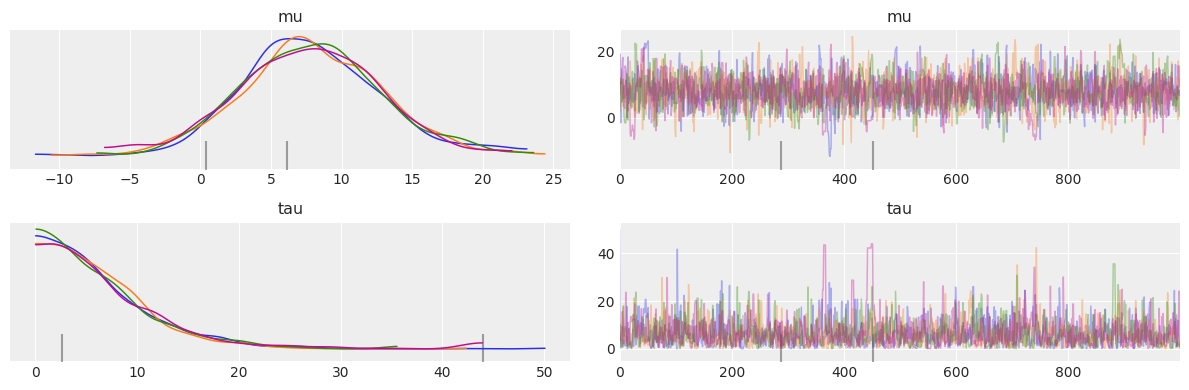

In [9]:
# (a) mu, tau 의 트레이스 + 사후분포
az.plot_trace(idata, var_names=["mu", "tau"], compact=False)
plt.tight_layout(); plt.show()

C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\2022012808.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


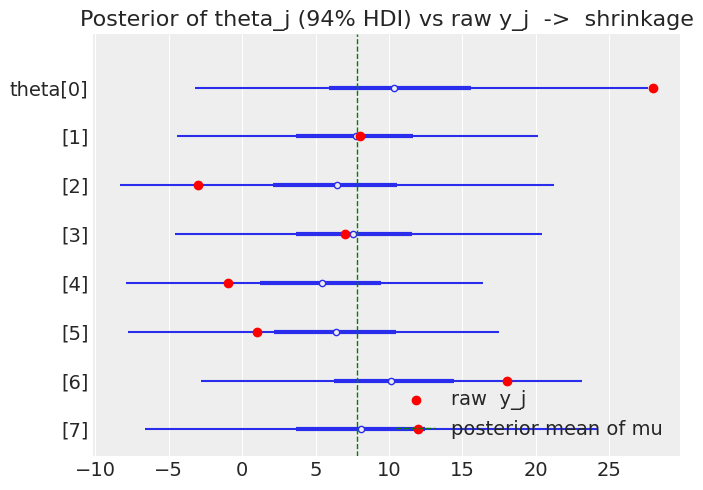

In [10]:
# (b) theta_j 의 사후분포 (forest) 와 원래 추정치 y_j 비교 -> 축소(shrinkage)
fig, ax = plt.subplots(figsize=(7, 5))
az.plot_forest(idata, var_names=["theta"], combined=True, ax=ax)
ylocs = ax.get_yticks()
ax.scatter(y[::-1], ylocs, color="red", zorder=5, label="raw  y_j")
ax.axvline(float(idata.posterior["mu"].mean()), color="green", ls="--",
           lw=1, label="posterior mean of mu")
ax.legend(loc="lower right")
ax.set_title("Posterior of theta_j (94% HDI) vs raw y_j  ->  shrinkage")
plt.tight_layout(); plt.show()

C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\530482615.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


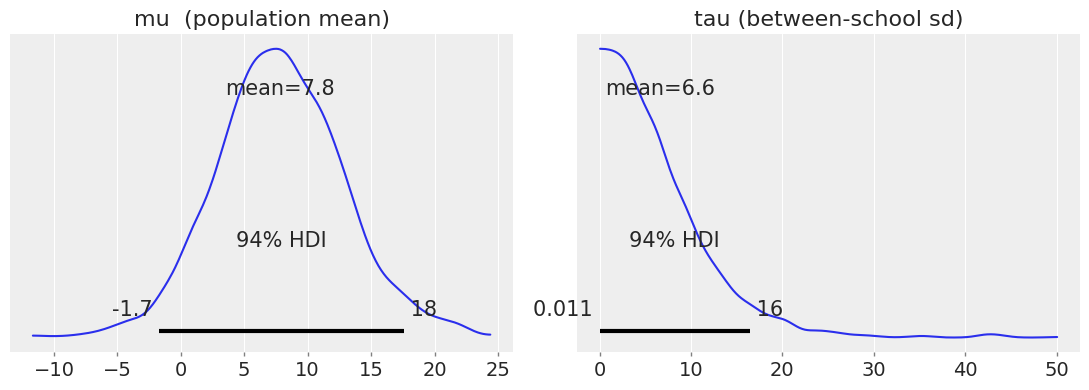

In [11]:
# (c) mu, tau 사후분포
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
az.plot_posterior(idata, var_names=["mu"], ax=axes[0])
az.plot_posterior(idata, var_names=["tau"], ax=axes[1])
axes[0].set_title("mu  (population mean)")
axes[1].set_title("tau (between-school sd)")
plt.tight_layout(); plt.show()

## 7. 축소 (Shrinkage)

조건부 사후평균은 $y_j$ 와 $\mu$ 의 정밀도 가중평균이다:

$$\mathrm{E}(\theta_j\mid\mu,\tau,y)=(1-B_j)\,y_j+B_j\,\mu,\qquad
B_j=\frac{\tau^{-2}}{\tau^{-2}+\sigma_j^{-2}}.$$

$B_j$ 는 $y_j$ 가 전체 평균 $\mu$ 로 끌려가는 **축소 크기**다. $\sigma_j$ 가 클수록(=관측이 부정확할수록)
$B_j$ 가 커져 더 많이 축소된다.

C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\1880345437.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


school  y_j  sigma_j  post_mean_theta  shrinkage B_j
     E -1.0      9.0             5.07          0.693
     B  8.0     10.0             7.73          0.723
     G 18.0     10.0            10.72          0.723
     D  7.0     11.0             7.49          0.749
     F  1.0     11.0             6.05          0.749
     A 28.0     15.0            11.39          0.825
     C -3.0     16.0             6.04          0.839
     H 12.0     18.0             8.33          0.862


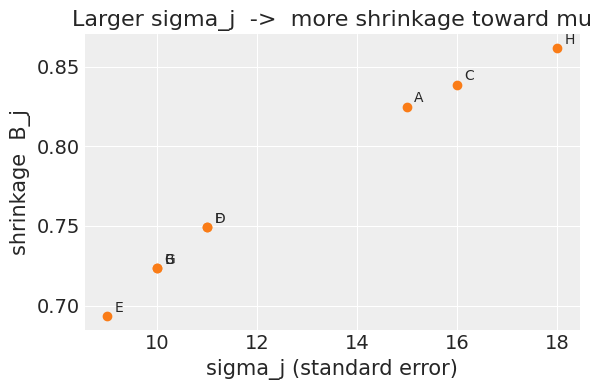

In [12]:
# 사후표본으로 평균 축소 크기 B_j 계산
tau_draws = idata.posterior["tau"].values.ravel()
B = np.array([np.mean((1/tau_draws**2) / (1/tau_draws**2 + 1/sigma[j]**2))
              for j in range(J)])
post_theta_mean = idata.posterior["theta"].mean(dim=("chain", "draw")).values

shrink_df = pd.DataFrame({
    "school": schools, "y_j": y, "sigma_j": sigma,
    "post_mean_theta": np.round(post_theta_mean, 2),
    "shrinkage B_j": np.round(B, 3),
}).sort_values("sigma_j")
print(shrink_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sigma, B, color="C1")
for j in range(J):
    ax.annotate(schools[j], (sigma[j], B[j]), textcoords="offset points", xytext=(5, 3))
ax.set_xlabel("sigma_j (standard error)")
ax.set_ylabel("shrinkage  B_j")
ax.set_title("Larger sigma_j  ->  more shrinkage toward mu")
plt.tight_layout(); plt.show()

C:\Users\yongduek\AppData\Local\Temp\ipykernel_19364\1137838605.py:10: UserWarning: The figure layout has changed to tight
  ax.legend(); plt.tight_layout(); plt.show()


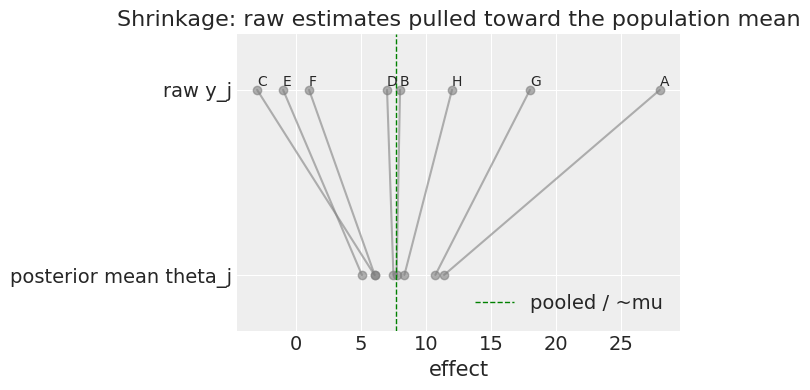

In [13]:
# 원래 추정치 y_j 가 사후평균으로 얼마나 끌려오는지 시각화
fig, ax = plt.subplots(figsize=(7, 4))
for j in range(J):
    ax.plot([y[j], post_theta_mean[j]], [1, 0], "o-", color="grey", alpha=0.6)
    ax.annotate(schools[j], (y[j], 1.02))
ax.axvline(pooled_mean, color="green", ls="--", lw=1, label="pooled / ~mu")
ax.set_yticks([0, 1]); ax.set_yticklabels(["posterior mean theta_j", "raw y_j"])
ax.set_ylim(-0.3, 1.3); ax.set_xlabel("effect")
ax.set_title("Shrinkage: raw estimates pulled toward the population mean")
ax.legend(); plt.tight_layout(); plt.show()

## 8. 사후 확률적 질문 (Posterior probability statements)

계층 모델의 사후표본으로 직접 확률을 계산할 수 있다. 

'개별 추정' 관점이 함의하는
과장된 확률(예: A 의 참 효과가 28 을 넘을 확률 50%)과 대조된다.

In [14]:
theta_s = idata.posterior["theta"].values.reshape(-1, J)  # (samples, J)

p_A_gt_28 = np.mean(theta_s[:, 0] > 28)
print(f"P(theta_A > 28)            = {p_A_gt_28:.3f}   (개별추정 관점이면 ~0.5)")

print("\nP(theta_A > theta_j):")
for j in range(1, J):
    print(f"  A vs {schools[j]}: {np.mean(theta_s[:,0] > theta_s[:,j]):.3f}")

P(theta_A > 28)            = 0.041   (개별추정 관점이면 ~0.5)

P(theta_A > theta_j):
  A vs B: 0.646
  A vs C: 0.677
  A vs D: 0.654
  A vs E: 0.738
  A vs F: 0.701
  A vs G: 0.532
  A vs H: 0.617


## 9. 결론 (Conclusion)

계층 모델은 '개별 추정'과 '완전 통합' 사이의 **고정된 중간값**이 아니라, 

둘을 특수한 극한 ($\tau\to\infty$, $\tau\to0$)으로 포함하는 **일반 모델**이다. 

데이터가 $\tau$ 를 통해 학교 간 유사성의 정도를 추정하고, 그 결과로 각 $y_j$ 가 $\mu$ 쪽으로 적절히 **축소**된다.

표준오차가 큰 학교일수록 더 많이 축소되며, A 의 +28 같은 극단값은 약 11 부근으로 완화된다.

---

## 부록 (Appendix). 사후확률 분포의 수학적 유도 (Derivation)

### A.1 결합 사후분포 (joint posterior)

모형: $y_j\mid\theta_j\sim\mathcal N(\theta_j,\sigma_j^2)$, $\theta_j\mid\mu,\tau\sim\mathcal N(\mu,\tau^2)$,
$p(\mu,\tau)\propto1$. 비정규화 결합 사후분포는

$$
\begin{aligned}
p(\boldsymbol\theta,\mu,\tau\mid \mathbf y,\boldsymbol\sigma)
&\propto p(\mu,\tau)\prod_{j=1}^J p(\theta_j\mid\mu,\tau)\,p(y_j\mid\theta_j,\sigma_j)\\
&\propto \prod_{j=1}^J \frac{1}{\tau\sigma_j}
\exp\!\left(-\frac{(\theta_j-\mu)^2}{2\tau^2}-\frac{(y_j-\theta_j)^2}{2\sigma_j^2}\right).
\end{aligned}
$$

### A.2 $\theta_j$ 에 대해 완전제곱 (completing the square)

지수부를 $\theta_j$ 의 이차식으로 묶는다. 분모를 통분하면

$$
\frac{(\theta_j-\mu)^2}{\tau^2}+\frac{(y_j-\theta_j)^2}{\sigma_j^2}
=\frac{\theta_j^2(\sigma_j^2+\tau^2)-2\theta_j(\mu\sigma_j^2+y_j\tau^2)+\sigma_j^2\mu^2+\tau^2y_j^2}{\tau^2\sigma_j^2}.
$$

$a=\sigma_j^2+\tau^2,\ b=\mu\sigma_j^2+y_j\tau^2,\ c=\sigma_j^2\mu^2+\tau^2y_j^2$ 로 두면
$a\theta_j^2-2b\theta_j+c=a\left(\theta_j-\tfrac{b}{a}\right)^2-\tfrac{b^2}{a}+c$. 따라서

$$
=\Big(\tfrac{1}{\sigma_j^2}+\tfrac{1}{\tau^2}\Big)\big(\theta_j-\hat\theta_j\big)^2
+\frac{(\mu-y_j)^2}{\sigma_j^2+\tau^2},
$$

여기서

$$
\hat\theta_j=\frac{\dfrac{y_j}{\sigma_j^2}+\dfrac{\mu}{\tau^2}}
{\dfrac{1}{\sigma_j^2}+\dfrac{1}{\tau^2}}
=\frac{\mu\sigma_j^2+y_j\tau^2}{\sigma_j^2+\tau^2},
\qquad
V_j=\Big(\tfrac{1}{\sigma_j^2}+\tfrac{1}{\tau^2}\Big)^{-1}.
$$

(잔여항 $c-b^2/a$ 를 정리하면 정확히 $\dfrac{\sigma_j^2\tau^2(\mu-y_j)^2}{\sigma_j^2+\tau^2}$ 가 되고,
$\tau^2\sigma_j^2$ 로 나누면 $\dfrac{(\mu-y_j)^2}{\sigma_j^2+\tau^2}$ 이다.)

### A.3 조건부 + 주변 분해 (conditional + marginal)

정규화 상수도 정확히 갈라진다. $\dfrac{1}{\sigma_j^2}+\dfrac{1}{\tau^2}=\dfrac{\sigma_j^2+\tau^2}{\sigma_j^2\tau^2}$
이므로

$$
\frac{1}{\tau\sigma_j}=\sqrt{\frac{\tfrac{1}{\sigma_j^2}+\tfrac{1}{\tau^2}}{\sigma_j^2+\tau^2}}
=\underbrace{\sqrt{\tfrac{1}{\sigma_j^2}+\tfrac{1}{\tau^2}}}_{N(\hat\theta_j,V_j)\ \text{정규화}}
\times\underbrace{\frac{1}{\sqrt{\sigma_j^2+\tau^2}}}_{N(\mu,\sigma_j^2+\tau^2)\ \text{정규화}} .
$$

따라서

$$
p(\boldsymbol\theta,\mu,\tau\mid\mathbf y,\boldsymbol\sigma)
\propto\prod_{j=1}^J
\underbrace{\mathcal N\!\big(\theta_j\mid\hat\theta_j,\,V_j\big)}_{\text{조건부 사후 } p(\theta_j\mid\mu,\tau,y)}
\;\times\;
\underbrace{\mathcal N\!\big(y_j\mid\mu,\,\sigma_j^2+\tau^2\big)}_{\text{주변 } p(y_j\mid\mu,\tau)} .
$$

균일 사전 $p(\mu,\tau)\propto1$ 하에서 **주변 사후분포**는

$$
p(\mu,\tau\mid\mathbf y,\boldsymbol\sigma)\ \propto\ \prod_{j=1}^J
\mathcal N\!\big(y_j\mid\mu,\ \sigma_j^2+\tau^2\big).
$$

### A.4 재모수화와 로그 사후 (reparameterization)

$\lambda_1=\mu,\ \lambda_2=\log\tau$ (그래서 $\tau=e^{\lambda_2}>0$ 가 실선 전체로 펼쳐짐).
야코비안 $|\mathrm d\tau/\mathrm d\lambda_2|=e^{\lambda_2}$ 가 곱해지므로 로그 사후는

$$
\log p(\lambda_1,\lambda_2\mid\mathbf y,\boldsymbol\sigma)
\propto \sum_{j=1}^J\!\left[-\tfrac12\log\!\big(e^{2\lambda_2}+\sigma_j^2\big)
-\frac{(\lambda_1-y_j)^2}{2(\sigma_j^2+e^{2\lambda_2})}\right]+\lambda_2 .
$$

마지막 항 $+\lambda_2$ 가 야코비안에서 온다.

### A.5 축소 형태 (shrinkage form)

$$
\hat\theta_j=(1-B_j)\,y_j+B_j\,\mu,\qquad
B_j=\frac{\tau^{-2}}{\tau^{-2}+\sigma_j^{-2}} .
$$

$\sigma_j$ 가 클수록 $\sigma_j^{-2}$ 가 작아져 $B_j$ 가 커지므로, 부정확한 학교일수록 전체 평균 $\mu$ 쪽으로
더 많이 축소된다.

> 위 유도(A.1–A.5)의 핵심 항등식들은 본 분석 과정에서 기호 대수(SymPy)로 모두 검증되었다:
> 지수부 분해, $\hat\theta_j$ 형태 일치, 정규화 상수 분리, 잔여항, 축소 형태가 모두 항등적으로 성립한다.

### 참고문헌 (References)
- A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, D. B. Rubin (2013).
  *Bayesian Data Analysis*, 3rd ed. (8 schools: §5.5).
- Jun Yu Tan, "Learning Bayesian Hierarchical Modeling from 8 Schools."
